In [100]:
import ROOT
canvas = ROOT.TCanvas("canvas", "canvas", 600, 600)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


In [2]:
sim_file_name = "/lustre/r3b/pulrich/Down/sim/4GeV.output.root"

file = ROOT.TFile(sim_file_name, "read")

In [6]:
data_tree = file.Get("evt;8")
data_frame = ROOT.RDataFrame(data_tree, {"NeulandPoints.fELoss"})

In [39]:
hist = data_frame.Define("energy", "NeulandPoints.fELoss * 1000 / 5").Histo1D(("hist", "hist", 400, 0, 3), "energy")

Peak position: 1.7316478049913817


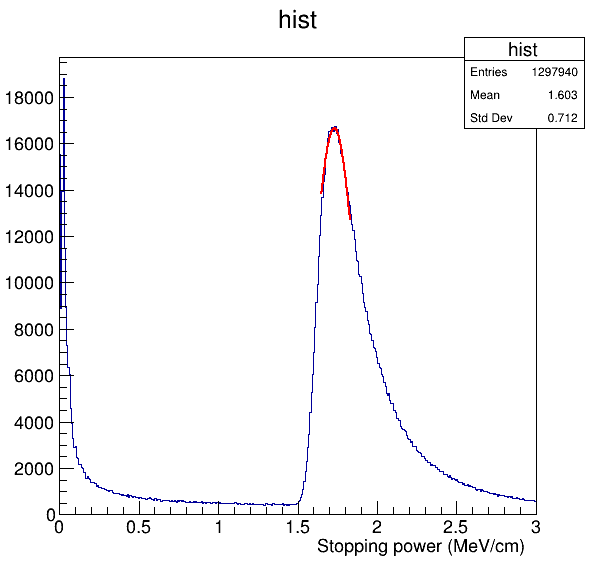

In [101]:
res = hist.Fit("gaus", "SQ", "", 1.65, 1.83)
hist.GetXaxis().SetTitle("Stopping power (MeV/cm)")
# res.Print("V")
print(f"Peak position: {res.Parameter(res.Index("Mean"))}")
hist.Draw()
canvas.Draw()

In [109]:
!neuland ana -c "ana_config.json"

[INFO] R3BNeulandApp.h:192:ParseApplicationOptionImp(): Reading the configuration from the json file "ana_config.json".
[INFO] R3BNeulandApp.cxx:78:init(): Initializaing application ...
[DEBUG] FairRootFileSink created------------
[DEBUG] Creating a new R3BFileSource!
[INFO] R3BNeulandApp.cxx:177:add_inout_files(): Filesource2: Set to run id 999
[INFO] R3BFileSource2.cxx:256:AddFileName(): Adding /lustre/r3b/pulrich/Down/sim/4GeV.output.root to file source

[DEBUG] R3BFileSource2.cxx:391:Intitialize(): Successfully extract RunID "999" from root file "/lustre/r3b/pulrich/Down/sim/4GeV.output.root"
[DEBUG] R3BFileSource2.cxx:173:GetDataFromAnyFolder(): looking for r3broot
[DEBUG] R3BFileSource2.cxx:177:GetDataFromAnyFolder(): r3broot has been found!
[WARN] No time based branch list in input file
[DEBUG] R3BFileSource2.cxx:173:GetDataFromAnyFolder(): looking for r3broot
[DEBUG] R3BFileSource2.cxx:177:GetDataFromAnyFolder(): r3broot has been found!
[INFO] R3BNeulandApp.cxx:199:add_inout_pa

Peak position: 1.7050481622892644


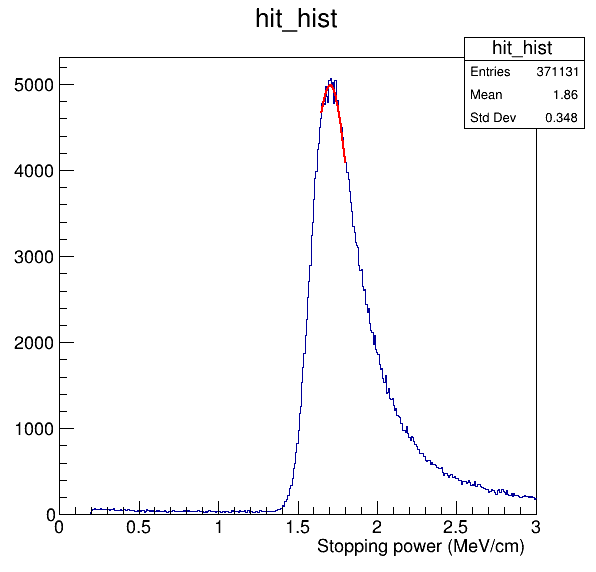

In [108]:
ana_file_name = "/lustre/r3b/ywang/test/test_muon/ana.output.root"
# hit_file = ROOT.TFile(ana_file_name, "read")
# hit_file.Get("evt;3").Print()

hit_dataframe = ROOT.RDataFrame("evt", ana_file_name, {"NeulandHits.energy"})
hit_hist = hit_dataframe.Define("stopping_power", "NeulandHits.energy / 5").Histo1D(("hit_hist", "hit_hist", 400, 0., 3), "stopping_power")
res = hit_hist.Fit("gaus", "SQ", "", 1.65, 1.8)
hit_hist.GetXaxis().SetTitle("Stopping power (MeV/cm)")
print(f"Peak position: {res.Parameter(res.Index("Mean"))}")
hit_hist.Draw()
canvas.Draw()

Testing for Paula's config

In [92]:
!neuland ana -c "/lustre/r3b/ywang/test/test_muon/paula_config.json"

[INFO] R3BNeulandApp.h:192:ParseApplicationOptionImp(): Reading the configuration from the json file "/lustre/r3b/ywang/test/test_muon/paula_config.json".
[INFO] R3BNeulandApp.cxx:78:init(): Initializaing application ...
OBJ: FairParRootFile	/lustre/r3b/pulrich/hpc_output/ParameterFiles/new_cos.par.root	 : 0 at: 0x21aa4b90
Root file I/O /lustre/r3b/pulrich/hpc_output/ParameterFiles/new_cos.par.root is open
detector I/Os:  FairGenericParIo
Info in <TGeoManager::CloseGeometry>: Geometry loaded from file...
Info in <TGeoManager::SetTopVolume>: Top volume is cave. Master volume is cave
Info in <TGeoNavigator::BuildCache>: --- Maximum geometry depth set to 100
Info in <TGeoManager::Voxelize>: Voxelizing...
Info in <TGeoManager::CountLevels>: max level = 3, max placements = 1300
Info in <TGeoManager::CloseGeometry>: 5202 nodes/ 6 volume UID's in FAIR geometry
Info in <TGeoManager::CloseGeometry>: ----------------modeler ready----------------
OBJ: FairParRootFile	/lustre/r3b/pulrich/hpc_outpu

In [93]:
paula_file_name = "/lustre/r3b/ywang/test/test_muon/test.output.root"
paula_dataframe = ROOT.RDataFrame("evt", paula_file_name, {"NeulandHits.energy"})
paula_hist = paula_dataframe.Define("stopping_power", "NeulandHits.energy / 5").Histo1D(("hit_hist", "hit_hist", 400, 0., 3), "stopping_power")

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      15.8629
NDf                       =           17
Edm                       =  1.87063e-07
NCalls                    =          124
Constant                  =      13175.1   +/-   37.4503     
Mean                      =      1.71009   +/-   0.0013301   
Sigma                     =     0.149516   +/-   0.00409946   	 (limited)

Covariance Matrix:

            	    Constant        Mean       Sigma
Constant    	      1402.5    0.011809    -0.10502
Mean        	    0.011809  1.7692e-06 -3.3111e-06
Sigma       	    -0.10502 -3.3111e-06  1.6808e-05

Correlation Matrix:

            	    Constant        Mean       Sigma
Constant    	           1     0.23708    -0.68398
Mean        	     0.23708           1    -0.60719
Sigma       	    -0.68398    -0.60719           1


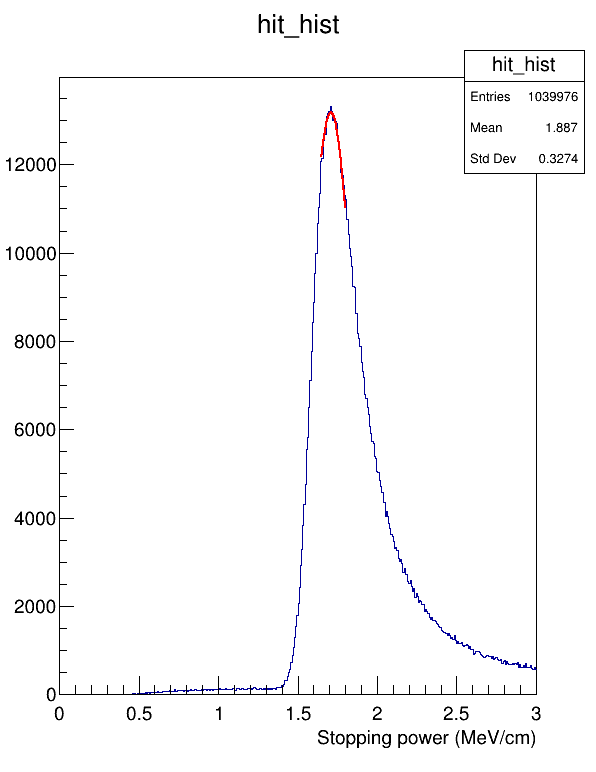

In [94]:
res = paula_hist.Fit("gaus", "SQ", "", 1.65, 1.8)
paula_hist.GetXaxis().SetTitle("Stopping power (MeV/cm)")
res.Print("V")
paula_hist.Draw()
canvas.Draw()
paula_hist.Draw()
canvas.Draw()